# 1. Precipitation Bias Correction — Empirical Quantile Mapping (EQM)


In [ ]:
import netCDF4 as nc
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

NC_FILE   = r"D:\Thesis Data\Data_Ali _Pakistan\PREC_NEP.nc"
base_path = Path(r"C:\Users\Apechhya Aryal\Desktop\forpaper\Mustang temp_rainfall")

OBS_FILES = {
    'Jomsom':      base_path / "Jomsom.csv",
    'Thakmarpha':  base_path / "Thakmarpha.csv",
    'Lete':        base_path / "Lete.csv",
    'Ranipauwa':   base_path / "Ranipauwa.csv",
    'Samar_Gaun':  base_path / "Samar_Gaun.csv",
    'Dhakarjhong': base_path / "Dhakarjhong.csv",
    'Chhoser':     base_path / "Chhoser.csv",
}
OUTPUT_DIR = r"C:\Users\Apechhya Aryal\Desktop\forpaper\rainfallcorrected"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# DHM-verified coordinates
STATIONS = {
    'Jomsom':      {'id':601,'lat':28.78401,'lon':83.72982,'elev':2741},
    'Thakmarpha':  {'id':604,'lat':28.73887,'lon':83.68183,'elev':2655},
    'Lete':        {'id':607,'lat':28.63273,'lon':83.60922,'elev':2490},
    'Ranipauwa':   {'id':608,'lat':28.81556,'lon':83.86222,'elev':3671},
    'Samar_Gaun':  {'id':624,'lat':28.96202,'lon':83.80163,'elev':3610},
    'Dhakarjhong': {'id':625,'lat':28.82359,'lon':83.73951,'elev':3200},
    'Chhoser':     {'id':633,'lat':29.22713,'lon':83.97982,'elev':3886},
}
PERIOD_START, PERIOD_END = '1981-01-01', '2014-12-31'
print("Config set!")

Config set!


In [ ]:

def load_obs(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['dateTime']).dt.normalize()
    df = df.rename(columns={'value':'Obs'})[['Date','Obs']].set_index('Date').sort_index()
    return df[~df.index.duplicated(keep='first')].dropna()['Obs']

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dl = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def find_nearest_valid(lats, lons, valid_mask, target_lat, target_lon):
    """Nearest valid (unmasked) grid cell by great-circle distance, with outward search."""
    LON, LAT = np.meshgrid(lons, lats)
    d = haversine(target_lat, target_lon, LAT, LON)
    d = np.where(valid_mask, d, np.inf)
    if np.isfinite(d).any():
        li, lni = np.unravel_index(np.nanargmin(d), d.shape)
        return int(li), int(lni)

    li = int(np.argmin(np.abs(lats - target_lat)))
    lni = int(np.argmin(np.abs(lons - target_lon)))
    return li, lni

def build_qm(obs_vals, nc_vals, nq=100):
    """Empirical quantile-mapping transfer function (nq+1 quantiles, piecewise linear)."""
    qs = np.linspace(0, 100, nq+1)
    return interp1d(np.percentile(nc_vals, qs), np.percentile(obs_vals, qs),
                    kind='linear', bounds_error=False,
                    fill_value=(np.percentile(obs_vals, 0), np.percentile(obs_vals, 100)))

def apply_qm(tf, series):
    return pd.Series(tf(series.values), index=series.index)

def calc_metrics(obs, sim):
    """KGE is the Gupta et al. (2009) formulation."""
    m = ~(np.isnan(obs) | np.isnan(sim)); o, s = obs[m], sim[m]
    if len(o) < 12: return {}
    bias = np.mean(s) - np.mean(o)
    pbias = 100*bias/np.mean(o) if np.mean(o) != 0 else np.nan
    rmse = np.sqrt(np.mean((s-o)**2)); r, _ = pearsonr(o, s)
    nse = 1 - np.sum((o-s)**2)/np.sum((o-np.mean(o))**2)
    a = np.std(s)/np.std(o); b = np.mean(s)/np.mean(o)
    kge = 1 - np.sqrt((r-1)**2 + (a-1)**2 + (b-1)**2)
    return {'Bias':round(bias,3),'PBIAS':round(pbias,1),'RMSE':round(rmse,3),
            'R2':round(r**2,4),'NSE':round(nse,3),'KGE':round(kge,3)}
print("Helpers loaded!")

Helpers loaded!


In [3]:
ds = nc.Dataset(NC_FILE)
lons = ds.variables['lon'][:]; lats = ds.variables['lat'][:]
times = nc.num2date(ds.variables['time'][:], ds.variables['time'].units)
dates_nc = pd.to_datetime([f'{t.year}-{t.month:02d}-{t.day:02d}' for t in times])
pvar = ds.variables['precip']
d0 = np.ma.filled(pvar[0,:,:], np.nan); valid_mask = ~np.isnan(d0)
print(f'NC period: {dates_nc[0].date()} to {dates_nc[-1].date()}, {len(dates_nc)} days')

nc_prec = {}
for s, meta in STATIONS.items():
    li, lni = find_nearest_valid(lats, lons, valid_mask, meta['lat'], meta['lon'])
    vals = np.clip(np.ma.filled(pvar[:, li, lni], 0.0), 0, None)
    nc_prec[s] = pd.Series(vals, index=dates_nc)
    nc_prec[s] = nc_prec[s][~nc_prec[s].index.duplicated(keep='first')]
    dist_km = haversine(meta['lat'], meta['lon'], lats[li], lons[lni])
    print(f'  {s:<15} grid=({lats[li]:.3f},{lons[lni]:.3f})  {dist_km:5.1f} km  mean={nc_prec[s].mean():.2f} mm/day')

NC period: 1980-01-01 to 2016-12-31, 13515 days
  Jomsom          grid=(28.800,83.750)    2.7 km  mean=4.64 mm/day
  Thakmarpha      grid=(28.750,83.700)    2.2 km  mean=5.07 mm/day
  Lete            grid=(28.650,83.600)    2.1 km  mean=4.03 mm/day
  Ranipauwa       grid=(28.800,83.850)    2.1 km  mean=5.18 mm/day
  Samar_Gaun      grid=(28.950,83.800)    1.3 km  mean=4.46 mm/day
  Dhakarjhong     grid=(28.800,83.750)    2.8 km  mean=4.64 mm/day
  Chhoser         grid=(29.250,84.000)    3.2 km  mean=4.01 mm/day


In [4]:
full_range = pd.date_range(PERIOD_START, PERIOD_END, freq='D')
corrected_prec = {}
qm_metrics = []

for s, meta in STATIONS.items():
    nts = nc_prec[s]; obs = load_obs(OBS_FILES[s])
    cs = max(nts.index.min(), obs.index.min()); ce = min(nts.index.max(), obs.index.max())
    cal = pd.concat([nts.loc[cs:ce], obs.loc[cs:ce]], axis=1).dropna(); cal.columns = ['NC','Obs']
    tf = build_qm(cal['Obs'].values, cal['NC'].values, 100)
    corrected = np.clip(apply_qm(tf, nts), 0, None)
    # where the QM-corrected series is missing, fall back to raw NC (rare; outside overlap only)
    final = corrected.reindex(full_range).fillna(nts.reindex(full_range)).clip(lower=0)
    corrected_prec[s] = final

    pd.DataFrame({'Date': full_range.strftime('%Y-%m-%d'),
                  'PCPmm_corrected': final.values.round(4)}).to_csv(
        os.path.join(OUTPUT_DIR, f'{s}_precip_corrected.csv'), index=False)

    mm = pd.concat([nts.loc[cs:ce], obs.loc[cs:ce], corrected.loc[cs:ce]], axis=1).dropna()
    mm.columns = ['NC','Obs','QM']; mmm = mm.resample('ME').sum()
    mb = calc_metrics(mmm['Obs'].values, mmm['NC'].values)
    ma = calc_metrics(mmm['Obs'].values, mmm['QM'].values)
    qm_metrics.append({'Station':s, 'Stage':'Before', **mb})
    qm_metrics.append({'Station':s, 'Stage':'After',  **ma})
    flag = '  (raw KGE high - possible circularity, see NB4)' if s == 'Lete' else ''
    print(f'  {s:<15} PBIAS: {mb["PBIAS"]:+.0f}% -> {ma["PBIAS"]:+.1f}%   KGE: {mb["KGE"]:.2f} -> {ma["KGE"]:.3f}{flag}')

metrics_df = pd.DataFrame(qm_metrics)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'precip_qm_metrics.csv'), index=False)
display(metrics_df)

  Jomsom          PBIAS: +518% -> +1.3%   KGE: -5.80 -> 0.435
  Thakmarpha      PBIAS: +343% -> -1.4%   KGE: -3.75 -> 0.626
  Lete            PBIAS: +5% -> -0.2%   KGE: 0.94 -> 0.982  (raw KGE high - possible circularity, see NB4)
  Ranipauwa       PBIAS: +598% -> +4.5%   KGE: -6.40 -> 0.668
  Samar_Gaun      PBIAS: +650% -> -4.6%   KGE: -6.61 -> 0.587
  Dhakarjhong     PBIAS: +610% -> +6.1%   KGE: -6.39 -> 0.409
  Chhoser         PBIAS: +526% -> +0.7%   KGE: -5.32 -> 0.573


,Station,Stage,Bias,PBIAS,RMSE,R2,NSE,KGE
0,Jomsom,Before,114.581,518.2,170.914,0.2831,-43.050,-5.803
1,Jomsom,After,0.282,1.3,29.743,0.2645,-0.334,0.435
2,Thakmarpha,Before,115.313,342.9,170.981,0.4907,-23.295,-3.747
3,Thakmarpha,After,-0.460,-1.4,30.634,0.4954,0.220,0.626
4,Lete,Before,5.297,4.6,17.957,0.9726,0.966,0.935
5,Lete,After,-0.269,-0.2,16.552,0.9721,0.971,0.982
6,Ranipauwa,Before,122.286,597.9,187.851,0.5251,-36.940,-6.398
7,Ranipauwa,After,0.931,4.5,25.487,0.4653,0.302,0.668
8,Samar_Gaun,Before,105.748,650.4,163.481,0.3770,-32.137,-6.610
9,Samar_Gaun,After,-0.740,-4.6,23.112,0.3864,0.338,0.587


## 1.3 Differential Split-Sample Validation (out-of-sample)

The transfer function is calibrated on one half of the record and validated on the other half (and vice versa). Split at 2000 (record is 1981-2014, so windows are 1981-1999 and 2000-2014).

In [5]:
split_results = []
test_stations = ['Jomsom','Thakmarpha','Lete','Ranipauwa','Dhakarjhong','Samar_Gaun']

for s in test_stations:
    obs = load_obs(OBS_FILES[s]); nts = nc_prec[s]
    cs = max(nts.index.min(), obs.index.min()); ce = min(nts.index.max(), obs.index.max())
    overlap_yrs = (ce - cs).days / 365.25
    if overlap_yrs < 15:
        print(f'  {s}: {overlap_yrs:.0f} yr overlap - too short, skipped')
        continue
    split_date = pd.Timestamp('2000-01-01')
    if split_date <= cs or split_date >= ce:
        split_date = cs + (ce - cs)/2  # fallback to midpoint for short records

    for label, c1, c2, v1, v2 in [
        ('Cal 1981-1999 / Val 2000-2014', cs, split_date - pd.Timedelta(days=1), split_date, ce),
        ('Cal 2000-2014 / Val 1981-1999', split_date, ce, cs, split_date - pd.Timedelta(days=1))]:

        cc = pd.concat([nts.loc[c1:c2], obs.loc[c1:c2]], axis=1).dropna(); cc.columns = ['NC','Obs']
        if len(cc) < 365: continue
        tf = build_qm(cc['Obs'].values, cc['NC'].values, 100)
        vn = nts.loc[v1:v2]; vo = obs.loc[v1:v2]
        vc = pd.Series(np.clip(tf(vn.values), 0, None), index=vn.index)
        mg = pd.concat([vo, vn, vc], axis=1).dropna(); mg.columns = ['Obs','NC','QM']
        mm = mg.resample('ME').sum()
        mr = calc_metrics(mm['Obs'].values, mm['NC'].values)
        mq = calc_metrics(mm['Obs'].values, mm['QM'].values)
        split_results.append({'Station':s, 'Split':label,
            'Raw_KGE':mr['KGE'], 'QM_KGE':mq['KGE'],
            'Raw_PBIAS':mr['PBIAS'], 'QM_PBIAS':mq['PBIAS']})
        print(f'  {s:<13} {label}:  Raw KGE={mr["KGE"]:.2f} -> QM KGE={mq["KGE"]:.3f} (held-out)')

split_df = pd.DataFrame(split_results)
split_df.to_csv(os.path.join(OUTPUT_DIR, 'split_sample_validation.csv'), index=False)
display(split_df)

  Jomsom        Cal 1981-1999 / Val 2000-2014:  Raw KGE=-5.67 -> QM KGE=0.495 (held-out)
  Jomsom        Cal 2000-2014 / Val 1981-1999:  Raw KGE=-5.97 -> QM KGE=0.343 (held-out)
  Thakmarpha    Cal 1981-1999 / Val 2000-2014:  Raw KGE=-4.00 -> QM KGE=0.564 (held-out)
  Thakmarpha    Cal 2000-2014 / Val 1981-1999:  Raw KGE=-3.54 -> QM KGE=0.653 (held-out)
  Lete          Cal 1981-1999 / Val 2000-2014:  Raw KGE=0.93 -> QM KGE=0.980 (held-out)
  Lete          Cal 2000-2014 / Val 1981-1999:  Raw KGE=0.94 -> QM KGE=0.976 (held-out)
  Ranipauwa     Cal 1981-1999 / Val 2000-2014:  Raw KGE=-6.43 -> QM KGE=0.658 (held-out)
  Ranipauwa     Cal 2000-2014 / Val 1981-1999:  Raw KGE=-6.38 -> QM KGE=0.677 (held-out)
  Dhakarjhong   Cal 1981-1999 / Val 2000-2014:  Raw KGE=-5.93 -> QM KGE=0.363 (held-out)
  Dhakarjhong   Cal 2000-2014 / Val 1981-1999:  Raw KGE=-8.13 -> QM KGE=-0.031 (held-out)
  Samar_Gaun    Cal 1981-1999 / Val 2000-2014:  Raw KGE=-9.10 -> QM KGE=0.254 (held-out)
  Samar_Gaun    Cal 20

,Station,Split,Raw_KGE,QM_KGE,Raw_PBIAS,QM_PBIAS
0,Jomsom,Cal 1981-1999 / Val 2000-2014,-5.669,0.495,481.8,-15.3
1,Jomsom,Cal 2000-2014 / Val 1981-1999,-5.974,0.343,551.5,19.2
2,Thakmarpha,Cal 1981-1999 / Val 2000-2014,-4.003,0.564,357.2,4.1
3,Thakmarpha,Cal 2000-2014 / Val 1981-1999,-3.545,0.653,330.5,-5.3
4,Lete,Cal 1981-1999 / Val 2000-2014,0.933,0.980,5.2,0.6
5,Lete,Cal 2000-2014 / Val 1981-1999,0.936,0.976,4.1,-0.3
6,Ranipauwa,Cal 1981-1999 / Val 2000-2014,-6.434,0.658,590.4,-5.8
7,Ranipauwa,Cal 2000-2014 / Val 1981-1999,-6.377,0.677,603.8,10.1
8,Dhakarjhong,Cal 1981-1999 / Val 2000-2014,-5.928,0.363,553.4,-36.2
9,Dhakarjhong,Cal 2000-2014 / Val 1981-1999,-8.135,-0.031,803.2,62.7


## 1.4 Performance Plots

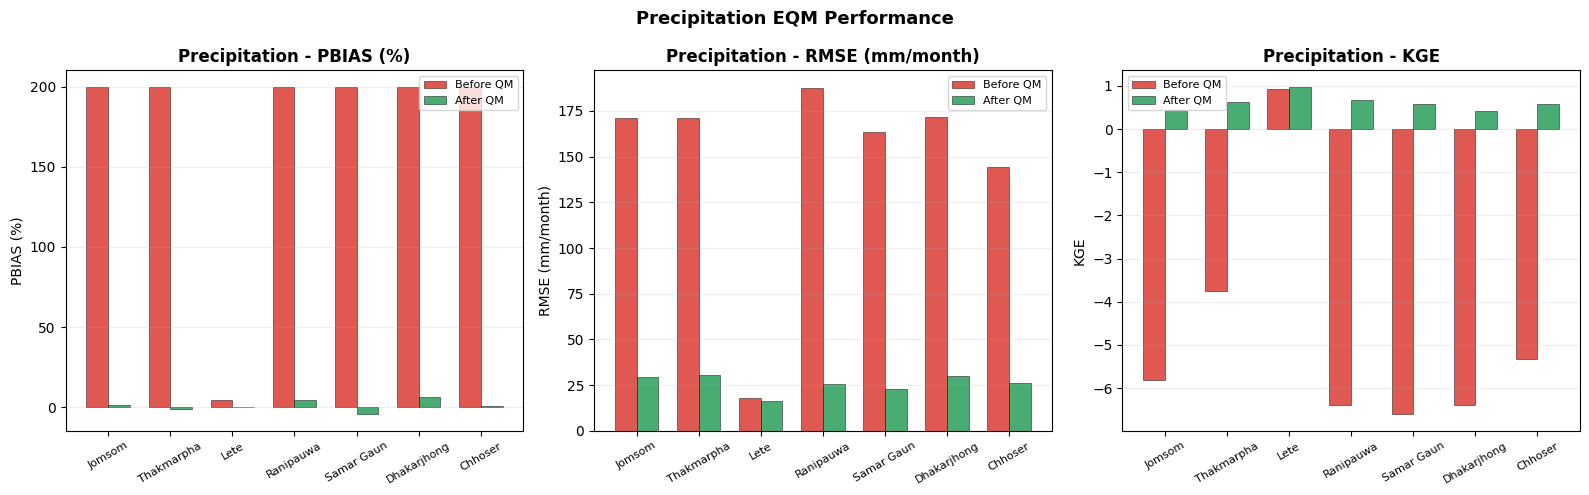

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
slist = list(STATIONS.keys()); x = np.arange(len(slist))
before = metrics_df[metrics_df['Stage']=='Before']; after = metrics_df[metrics_df['Stage']=='After']
w = 0.35
for ax, metric, yl in zip(axes, ['PBIAS','RMSE','KGE'], ['PBIAS (%)','RMSE (mm/month)','KGE']):
    bv = before[metric].values; av = after[metric].values
    if metric == 'PBIAS': bv = np.clip(bv, -200, 200)
    ax.bar(x-w/2, bv, w, color='#d73027', alpha=0.8, label='Before QM', edgecolor='k', lw=0.4)
    ax.bar(x+w/2, av, w, color='#1a9850', alpha=0.8, label='After QM', edgecolor='k', lw=0.4)
    ax.set_xticks(x); ax.set_xticklabels([s.replace('_',' ') for s in slist], fontsize=8, rotation=30)
    ax.set_ylabel(yl); ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')
    ax.set_title(f'Precipitation - {yl}', fontweight='bold')
plt.suptitle('Precipitation EQM Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'precip_qm_performance.png'), dpi=300, bbox_inches='tight')
plt.show()